In [1]:
!pip install polars -q
!pip install matplotlib -q

We will use polars library instead of pandas since it has proven to be faster for working with large datasets

# Table of Contents
* [Data preparation](#Data-preparation)
    * [Determining the time frame and file size](#Determining-the-time-frame-and-file-size)
    * [Uploading files for the time period](#Uploading-files-for-the-time-period)
    * [Data quality checks](#Data-quality-checks)
    * [Column transfomations](#Column-transfomations)
    * [Creating custom session ids](#Creating-custom-session-ids)
* [Data Exloporatory data analysis](#Exloporatory-data-analysis)
    * [Aggregated indicators](#Aggregated-indicators)
    * [Comparison of sessions with fine payments and without fine payments](#Comparison-of-sessions-with-fine-payments-and-without-fine-payments)


# Data preparation

## Determining the time frame and file size

In [2]:
import os
import pandas as pd
import polars as pl
from datetime import datetime
from matplotlib import pyplot as plt
pl.Config.set_tbl_rows(-1)
print(f"Доступно ядер в системе: {pl.thread_pool_size()}")

Доступно ядер в системе: 6


In [3]:
dir_path = '/home/jovyan/__AP25RAY/data/events'
items = os.listdir(dir_path)

In [4]:
file_path = str(dir_path + '/' +  items[1])
print(f' The size of the data for one day is {round(os.path.getsize(file_path) / 100 ** 3)} MB')

 The size of the data for one day is 311 MB


In [5]:
size = 0
for i in items[1:10]:
    file_path = str(dir_path + '/' + i)
    file_size = os.path.getsize(file_path)
    size += file_size
print(f'The size of the data for 10 days is {round(size / 1000 ** 3, 3)} GB')

The size of the data for 10 days is 3.772 GB


## Uploading files for the time period

In [6]:
%%time
dfs = []
for i in items[1:10]:
    file_path = str(dir_path + '/' + i)
    df = pl.read_csv(
        file_path,         
        has_header=True,         
        infer_schema_length=1000,
        ignore_errors=False, 
        schema_overrides={"appmetrica_device_id": pl.UInt64}
    )
    dfs.append(df)
df_week = pl.concat(dfs, how = 'vertical')

CPU times: user 12 s, sys: 5.06 s, total: 17.1 s
Wall time: 17 s


In [7]:
del(dfs)

In [8]:
df_week.shape

(8551962, 32)

## Data quality checks

In [9]:
df_week['profile_id'].null_count()

27031

In [10]:
df_week = df_week.filter(pl.col('profile_id').is_not_null())

In [11]:
df_week['session_id'].null_count()

0

In [12]:
# Session ids are not unique for each user
df_week.group_by('session_id').agg(
    pl.col('profile_id').n_unique()
).sort('profile_id', descending = True).head(5)

session_id,profile_id
i64,u32
10000000001,10354
10000000000,6231
10000000002,5418
10000000003,4751
10000000004,4136


In [13]:
# One profile can have a few installations
fiu =df_week.group_by('profile_id').agg(
    pl.col('installation_id').n_unique()
).sort('installation_id', descending = True).filter(
    pl.col('installation_id') > 1
)
print(fiu.height)

1067


In [14]:
# Most of the users with a few installations installed the app on the same device
df_week.filter(
    pl.col('profile_id').is_in(fiu['profile_id'].unique().to_list())
).group_by('profile_id').agg(
    pl.col('device_type').n_unique()
).sort('device_type', descending = True).head(15)

profile_id,device_type
str,u32
"""RSgKVIri.1627718394254""",2
"""04qkGqiy.1577641846243""",2
"""Cfy72Kl8.1590864155667""",2
"""UfEEV5Sd.1571000540396""",2
"""OCKDieyz.1569066361982""",2
"""8fSk6bYJ.1619796216946""",2
"""sIYGKK8c.1632748868386""",2
"""GNKpHJDx.1637454914839""",2
"""pbB84Ehj.1495390652973""",2


In [15]:
del(fiu)

**It makes sense to create a column with unique session id for further analysis**

## Column transformations

In [16]:
# Transforming the data type
df_week = df_week.with_columns([
    pl.col('event_datetime').str.to_datetime(),
    pl.col('event_receive_datetime').str.to_datetime(),
])

In [17]:
df_week = df_week.with_columns(
    pl.col('event_datetime').dt.date().alias('day')
)

## Creating custom session ids

- We create a "user_session_id" column which combines profile_id and the order of user's session
- A new session begins if the timeout between sessions is 30 minutes
- We will use both session_id and user_session_id in the analysis

In [18]:
df_week = df_week.sort(['profile_id', 'event_datetime'], descending = False)

In [19]:
df_week = df_week.with_columns(
      pl.col('event_datetime').diff().over('profile_id').dt.total_seconds().alias('time_since_last_event')
)
df_week = df_week.with_columns(
    (pl.col('time_since_last_event') > (60 * 15)).fill_null(True).alias('new_session')
)

In [20]:
df_week = df_week.with_columns(
    pl.col('new_session').cum_sum().over('profile_id').alias('session_group')
)

In [21]:
df_week = df_week.with_columns(
    pl.concat_str([
        pl.col('profile_id').cast(pl.Utf8),
        pl.lit('_'),
        pl.col('session_group').cast(pl.Utf8)
    ]).alias('user_session_id')
)

In [22]:
df_week = df_week.drop(['time_since_last_event','session_group'])

In [23]:
# Let's compare the features "session_id" and "user_session_id"
print(f"There are {df_week[['session_id', 'profile_id']].n_unique()} session_ids")
print(f"There are {df_week['user_session_id'].n_unique()} user_session_ids")

There are 1250427 session_ids
There are 771526 user_session_ids


The created feature contains half as many unique sessions as the original feature

# Exloporatory data analysis

## Aggregated indicators

In [24]:
# Let's count unique users in our dataset
print(f"There are {df_week['profile_id'].n_unique()} unique users in the app")

There are 331742 unique users in the app


In [25]:
print(f"There are {df_week['user_session_id'].n_unique()} unique sessions in the app")

There are 771526 unique sessions in the app


The average number of actions per user is 25.7


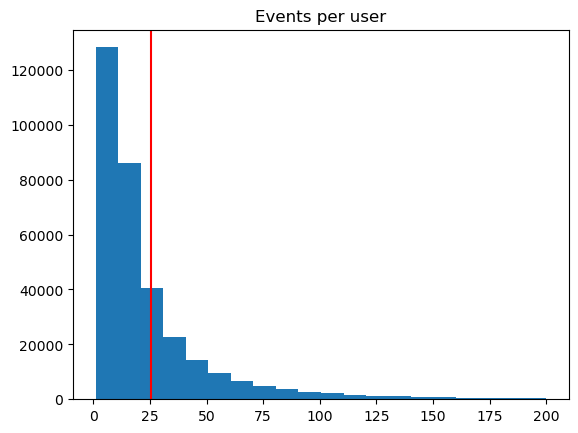

In [26]:
mean_events = df_week.group_by('profile_id').agg(
    pl.col('event_name').count()
)['event_name'].mean()


events_per_user = df_week.group_by('profile_id').agg(
    pl.col('event_name').count()
)
# Removing outliers
events_per_user = events_per_user.filter(
    pl.col('event_name') <= 200
)
plt.hist(events_per_user['event_name'], bins = 20)
plt.title('Events per user');
plt.axvline(mean_events, c = 'red')

print(f'The average number of actions per user is {round(mean_events,2)}')

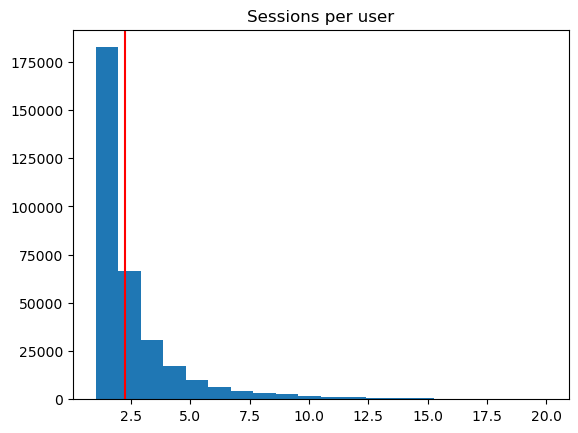

In [27]:
sessions_per_user = df_week.group_by('profile_id').agg(
    pl.col('user_session_id').n_unique()
)
sessions_per_user = sessions_per_user.filter(
    pl.col('user_session_id') <= 20
)
mean_sessions = sessions_per_user['user_session_id'].mean()

plt.hist(sessions_per_user['user_session_id'], bins = 20)
plt.title('Sessions per user')
plt.axvline(mean_sessions, c = 'red');

In [28]:
# Let's take a look at acions per day and sessions per day
mean_actions_per_day = df_week.group_by(['profile_id', 'day']).agg(
    pl.col('event_name').count()
)['event_name'].mean()

mean_session_per_day = df_week.group_by(['profile_id', 'day']).agg(
    pl.col('user_session_id').n_unique()
)['user_session_id'].mean()
print(f'The users have {round(mean_session_per_day, 1)} on average')
print(f'The make {round(mean_actions_per_day, 1)} actions per day on average')

The users have 1.2 on average
The make 13.3 actions per day on average


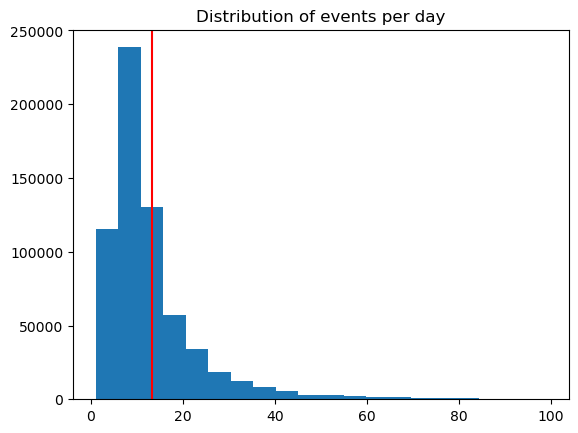

In [29]:
actions_per_day = df_week.group_by(['profile_id', 'day']).agg(
    pl.col('event_name').count()
)
actions_per_day = actions_per_day.filter(
    pl.col('event_name') < 100
)
plt.hist(actions_per_day['event_name'], bins = 20)
plt.title('Distribution of events per day')
plt.axvline(mean_actions_per_day, c = 'red');

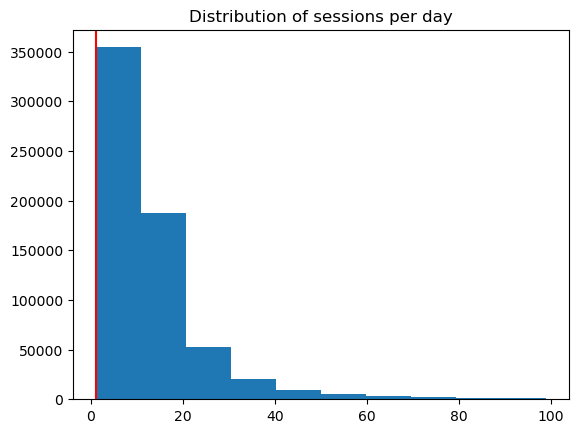

In [30]:
sessions_per_day = df_week.group_by(['profile_id', 'day']).agg(
    pl.col('user_session_id').count()
)
sessions_per_day = sessions_per_day.filter(
    pl.col('user_session_id') < 100
)
plt.hist(sessions_per_day['user_session_id'], bins = 10)
plt.title('Distribution of sessions per day')
plt.axvline(mean_session_per_day, c = 'red');

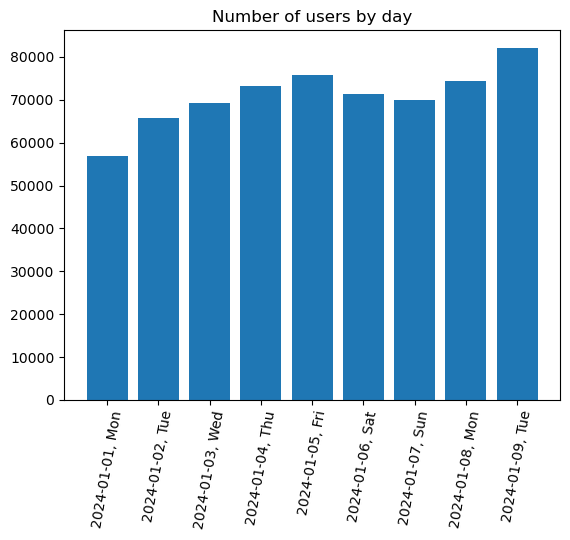

In [31]:
# Let's take a look at the distributions of sessions per weekday
df_week = df_week.with_columns(
    pl.col('event_datetime').dt.weekday().alias('weekday_number')
)

sessions_per_day = df_week.group_by(['day', 'weekday_number']).agg(
    pl.col('profile_id').n_unique()
).sort('day')

sessions_per_day = sessions_per_day.with_columns(
     pl.when(pl.col('weekday_number') == 1).then(pl.lit('Mon'))
     .when(pl.col('weekday_number') == 2).then(pl.lit('Tue'))
     .when(pl.col('weekday_number') == 3).then(pl.lit('Wed'))
     .when(pl.col('weekday_number') == 4).then(pl.lit('Thu'))
     .when(pl.col('weekday_number') == 5).then(pl.lit('Fri'))
     .when(pl.col('weekday_number') == 6).then(pl.lit('Sat'))
     .when(pl.col('weekday_number') == 7).then(pl.lit('Sun'))
     .alias('weekday_name')
)
sessions_per_day = sessions_per_day.with_columns(
    pl.concat_str([
        pl.col('day'),
        pl.lit(', '),
        pl.col('weekday_name')
    ]).alias('full_date')
)

plt.bar(sessions_per_day['full_date'], sessions_per_day['profile_id'])
plt.title('Number of users by day')
plt.xticks(rotation=80);

No increase in the number of users on weekends

In [32]:
del(mean_events, events_per_user, mean_actions_per_day, mean_session_per_day, actions_per_day, sessions_per_day)

## Paid and unpaid users analysis

In [ ]:
# Let's find users who have actually paid a fine through the app
df_paid = df_week.filter((pl.col('event_name').str.contains('Завешили оплату'))|
              (pl.col('event_name').str.contains('Завершили оплату'))
    )

In [ ]:
num_all_users = df_week['profile_id'].n_unique()
num_paid_users = df_paid['profile_id'].n_unique()

print(f'There are {num_paid_users} users who paid a fine through the app')
print(f'{round(num_paid_users / num_all_users * 100, 1)}% of all users paid a fine through the app')

In [ ]:
paid_users = df_paid.group_by('profile_id').agg(
    pl.col('session_id').n_unique()
).sort('session_id', descending = True)['profile_id'].to_list()

In [ ]:
df_unpaid = df_week.filter(
      ~(pl.col('event_name').str.contains('Завешили оплату')) &
      ~(pl.col('event_name').str.contains('Завершили оплату'))
    )
unpaid_users = df_unpaid.group_by('profile_id').agg(
    pl.col('session_id').n_unique()
).sort('session_id', descending = True)['profile_id'].to_list()

In [ ]:
def analyze_user(user_id: int, paid = True):
    user = df_week.filter(pl.col('profile_id') == user_id)
    user = user.unique()
    user = user.sort('event_datetime')
    print(f"The user had {user['session_id'].n_unique()} sessions")
    sessions = user.group_by('session_id').agg(
                pl.len()).sort('session_id')
    for s in sessions['session_id']:
        session = user.filter(pl.col('session_id') == s)
        date = session['event_datetime'][0]
        events = session['event_name'].to_list()
        logs = session['event_json'].to_list()
        print(date)
        for val in zip(events, logs):
            print(val)
        print('\n','***' * 30)
def analyze_session(session_id : int):
    session = df_week.filter(pl.col('session_id') == session_id)
    session = session.sort('event_datetime')
    events = session['event_name'].to_list()
    logs = session['event_json'].to_list()
    for val in zip(events, logs):
        print(val)

In [ ]:
analyze_user(paid_users[2], paid = True)

## Paid users analysis and comparison with unpaid users

In [ ]:
# Let's calculate the average number of sessions for paid users
mean_session_paid = df_week.filter(pl.col('profile_id').is_in(paid_users)).group_by(['profile_id']).agg(
    pl.col('session_id').n_unique()
)['session_id'].mean()
print(mean_session_paid)

In [ ]:
mean_sessions_unpaid = df_week.filter(pl.col('profile_id').is_in(unpaid_users)).group_by('profile_id').agg(
    pl.col('session_id').n_unique()
)['session_id'].mean()
print(mean_sessions_unpaid)

In [ ]:
paid_dur = df_week.filter(pl.col('profile_id').is_in(paid_users)).group_by(['profile_id', 'session_id']).agg(
    pl.col('event_datetime').max().alias('session_end'),
    pl.col('event_datetime').min().alias('session_start')
)
paid_dur = paid_dur.with_columns(
    delta = (pl.col('session_end') - pl.col('session_start')).dt.total_seconds()
)

unpaid_dur = df_week.filter(pl.col('profile_id').is_in(unpaid_users)).group_by(['profile_id','session_id']).agg(
    pl.col('event_datetime').max().alias('session_end'),
    pl.col('event_datetime').min().alias('session_start')
)
unpaid_dur = unpaid_dur.with_columns(
    delta = (pl.col('session_end') - pl.col('session_start')).dt.total_seconds()
)

In [ ]:
paid_dur.sort('delta', descending = True).head()

In [ ]:
print(f" The average session duration for paid users is {paid_dur['delta'].mean()} seconds")
print(f" The average session duration for unpaid users is {unpaid_dur['delta'].mean()} seconds")

- The average session duration for unpaid and paid users is almost equal
- The session id is not unique for each users, therefore there might be inaccuracies in the average length of a session calculation

In [ ]:
# For paid users
def plot_session_boundaries(df_dur, threshold, title, inverval = 20):
    binned_counts = (
        df_dur.group_by((pl.col("delta") / inverval).floor().alias("bin"))
        .agg([
            pl.len().alias("count"),
            pl.col("delta").min().alias("bin_min"), 
            pl.col("delta").max().alias("bin_max") 
        ])
        .sort("bin")
    )
    threshold = threshold
    binned_counts = binned_counts.with_columns(
        pl.when(pl.col("count") < threshold)
          .then(pl.lit("Other"))
          .otherwise(pl.format("{}-{}", "bin_min", "bin_max"))
          .alias("bin_bounds_str")
    )
    max_other = binned_counts.filter(
        pl.col('bin_bounds_str') == 'Other'
    )['bin_min'].max()
    
    min_other = binned_counts.filter(
        pl.col('bin_bounds_str') == 'Other'
    )['bin_min'].min()
    
    borders = f"{min_other}-{max_other}"
    binned_counts = binned_counts.with_columns(
        pl.col('bin_bounds_str').replace({'Other' : borders})
    )
    
    plt.figure(figsize = (12,5))
    plt.bar(binned_counts['bin_bounds_str'].to_list(), binned_counts['count'].to_list())
    plt.xticks(rotation = 75)
    plt.title(title)
    plt.show()
    
plot_session_boundaries(paid_dur, threshold = 20, 
                        title = 'Session duration histogram for paid users, seconds', inverval = 20)
    

In [ ]:
plot_session_boundaries(unpaid_dur, threshold = 1000, 
                        title = 'Session duration histogram for unpaid users, seconds', inverval = 20)

- Most of the sessions for both paid and unpaid users last from 0 to 19 seconds
- No difference in the session duration for two categories of users here

In [ ]:
event_paid_users = df_week.filter(
    pl.col('profile_id').is_in(paid_users)
)['event_name'].value_counts(normalize = True).sort('proportion', descending = True)
event_unpaid_users = df_week.filter(
    pl.col('profile_id').is_in(unpaid_users)
)['event_name'].value_counts(normalize = True).sort('proportion', descending = True)

In [ ]:
plt.figure(figsize = (16,10))
plt.barh(event_paid_users['event_name'][:15], event_paid_users['proportion'][:15])
plt.gca().invert_yaxis()
plt.title('The most frequent event in the sessions of paid users, %', fontsize = 16)
plt.show()

In [ ]:
plt.figure(figsize = (16,10))
plt.barh(event_unpaid_users['event_name'][:15], event_unpaid_users['proportion'][:15])
plt.gca().invert_yaxis()
plt.title('The most frequent events in the sessions of unpaid users, %', fontsize = 16)
plt.show()

- Hard to get any insights, it seems like there is no difference between actions of paid and unpaid users
- We can take a look at the actions which lead to fine payment

Let's take a look at the actions which are in sessions which ended with a fine payment

## Comparison of sessions with fine payments and without fine payments

Let's take a look at session durations which ended in a fine payment

In [33]:
sessions_with_payment = df_week.filter(
    pl.col('event_name').str.contains("Завершили оплату") |
    pl.col('event_name').str.contains("Завешили оплату")
).select(['user_session_id']).unique()
sessions_without_payment = df_week.join(
    sessions_with_payment,
    on=['user_session_id'],
    how='anti' 
).select(['user_session_id']).unique()
print(f'{len(sessions_with_payment)} sessions ended in a fine payment')
print(f"This constitutes {round(len(sessions_with_payment) / df_week['user_session_id'].n_unique() * 100, 2)}% of all sessions")
print('***' * 30)
print(f'{len(sessions_without_payment)} sessions ended without a fine payment')
print(f"This constitutes {round(len(sessions_without_payment) / df_week['user_session_id'].n_unique() * 100, 2)}% of all sessions")

2473 sessions ended in a fine payment
This constitutes 0.32% of all sessions
******************************************************************************************
769053 sessions ended without a fine payment
This constitutes 99.68% of all sessions


In [34]:
# Let's calculate the average number of events per session with and without payment
eps_fine = df_week.join(
    sessions_with_payment.select(['user_session_id']),
    on=['user_session_id'],
    how='inner'
).group_by(['user_session_id']).agg(
    pl.col('event_name').count().alias('total_events')
)
eps_fine_mean = eps_fine.select(
    pl.col('total_events').mean().alias('eps_fine_mean')
).item()

eps_no_fine = df_week.join(
    sessions_without_payment.select(['user_session_id']),
    on=['user_session_id'],
    how='inner'
).group_by(['user_session_id']).agg(
    pl.col('event_name').count().alias('total_events')
)
eps_nofine_mean = eps_no_fine.select(
    pl.col('total_events').mean().alias('eps_no_fine')
).item()


In [35]:
print(f'The average number of events per a session ending with a fine payment is {round(eps_fine_mean, 2)}')
print(f'The average number of events per a session ending without a fine payment is {round(eps_nofine_mean, 2)}')

The average number of events per a session ending with a fine payment is 40.84
The average number of events per a session ending without a fine payment is 10.95


In [36]:
eps_no_fine = eps_no_fine.filter(
    pl.col('total_events') <= 100
)

eps_fine = eps_fine.filter(
    pl.col('total_events') <= 100
)

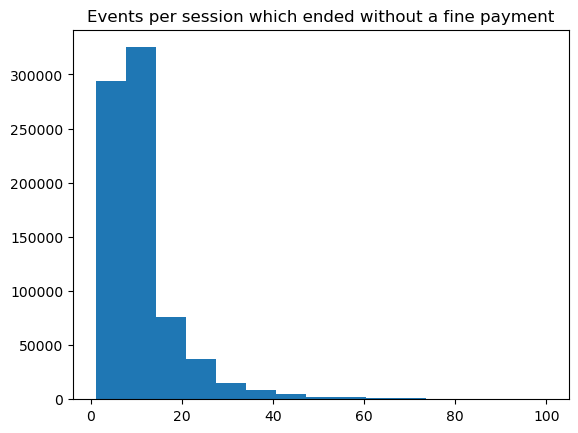

In [37]:
plt.hist(eps_no_fine['total_events'], bins = 15)
plt.title('Events per session which ended without a fine payment');

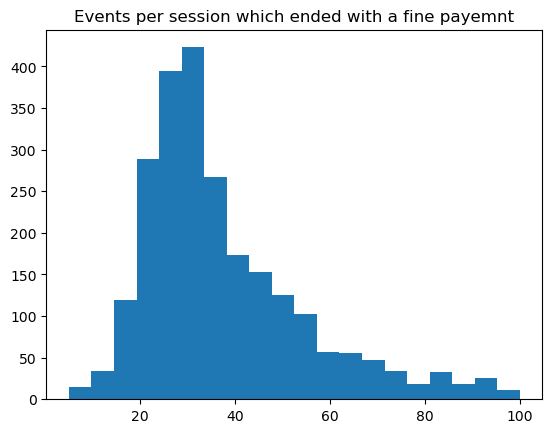

In [38]:
plt.hist(eps_fine['total_events'], bins = 20)
plt.title('Events per session which ended with a fine payemnt');

In [39]:
del(eps_fine, eps_no_fine)

In [40]:
# Let's calculate average duration and duration distributions of sessions with and without fine payment
# And then do the same task for paid and unpaid users
with_fine_dur = df_week.join(
    sessions_with_payment.select(['user_session_id']),
    on=['user_session_id'],
    how='inner'
).group_by(['user_session_id']).agg(
    pl.col('event_datetime').min().alias('session_start'),
    pl.col('event_datetime').max().alias('session_end')
)
with_fine_dur = with_fine_dur.with_columns(
    delta = (pl.col('session_end') - pl.col('session_start')).dt.total_seconds()
)
with_fine_dur = with_fine_dur.filter(
    pl.col('delta') <= 2000
)

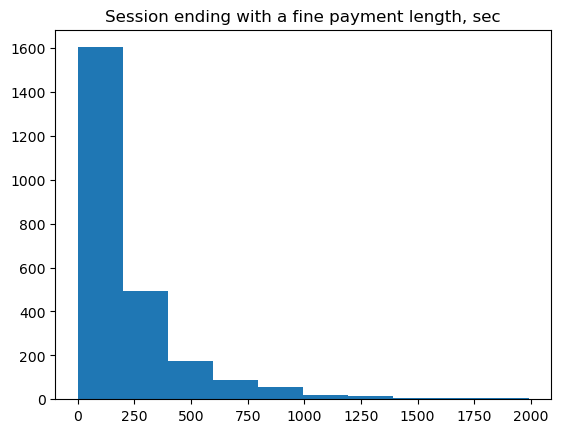

In [41]:
plt.hist(with_fine_dur['delta'], bins = 10)
plt.title('Session ending with a fine payment length, sec');

In [42]:
# Let's calculate average duration and duration distributions of sessions with and without fine payment
# And then do the same task for paid and unpaid users
without_fine_dur = df_week.join(
    sessions_without_payment.select(['user_session_id']),
    on=['user_session_id'],
    how='inner'
).group_by(['user_session_id']).agg(
    pl.col('event_datetime').min().alias('session_start'),
    pl.col('event_datetime').max().alias('session_end')
)
without_fine_dur = without_fine_dur.with_columns(
    delta = (pl.col('session_end') - pl.col('session_start')).dt.total_seconds()
)
without_fine_dur = without_fine_dur.filter(
    (pl.col('delta') <= 250)
)

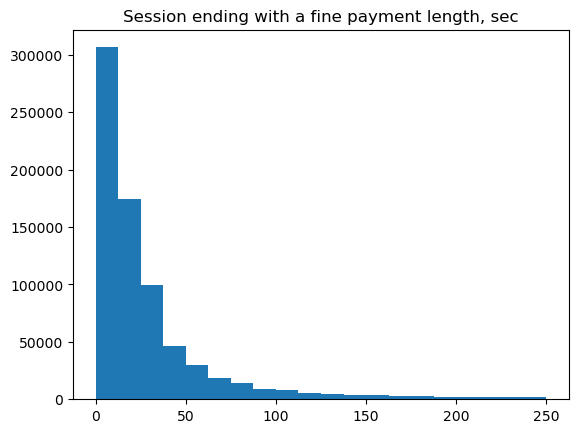

In [43]:
plt.hist(without_fine_dur['delta'], bins = 20)
plt.title('Session ending with a fine payment length, sec');

In [44]:
with_fine_dur_mean = with_fine_dur.select(
    pl.col('delta').median().alias('eps_no_fine')
).item()

without_fine_dur_mean = without_fine_dur.select(
    pl.col('delta').median().alias('eps_no_fine')
).item()


print(f'The length of a session ending with a fine payment is {round(with_fine_dur_mean, 2)} seconds')
print(f'The length of a session ending without a fine payment is {round(without_fine_dur_mean, 2)} seconds')

The length of a session ending with a fine payment is 136.0 seconds
The length of a session ending without a fine payment is 16.0 seconds


Sessions which ended with a fine payment are significantly longer on average and contain more events

In [45]:
del(without_fine_dur, with_fine_dur)

In [46]:
fine_dur = df_week.filter(
    pl.col('profile_id').is_in(paid_users) &
    pl.col('session_id').is_in(fine_sessions)
    ).group_by(['profile_id','session_id']).agg(
    pl.col('event_datetime').max().alias('session_end'),
    pl.col('event_datetime').min().alias('session_start')
)
fine_dur = fine_dur.with_columns(
    delta = (pl.col('session_end') - pl.col('session_start')).dt.total_seconds()
)
plot_session_boundaries(fine_dur, threshold = 20, 
                        title = 'Session duration histogram for sessions with a fine payment, seconds', inverval = 20)

NameError: name 'paid_users' is not defined

### Most common events analysis

In [48]:
# We can identify active and not active users
events_with_fine = df_week.join(
    sessions_with_payment.select(['user_session_id']),
    on=['user_session_id'],
    how='inner'
)['event_name'].value_counts(normalize = True).sort('proportion', descending = True)

events_without_fine = df_week.join(
    sessions_without_payment.select(['user_session_id']),
    on=['user_session_id'],
    how='inner'
)['event_name'].value_counts(normalize = True).sort('proportion', descending = True)

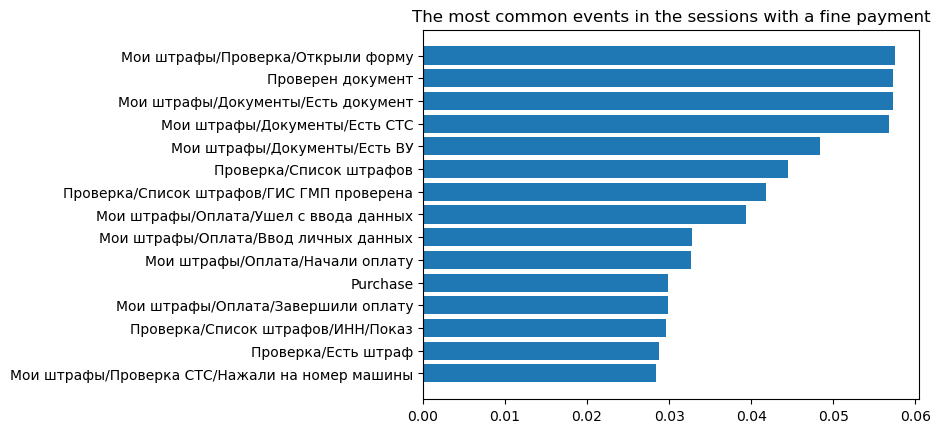

In [49]:
plt.barh(events_with_fine['event_name'][:15], events_with_fine['proportion'][:15])
plt.title("The most common events in the sessions with a fine payment")
plt.gca().invert_yaxis();

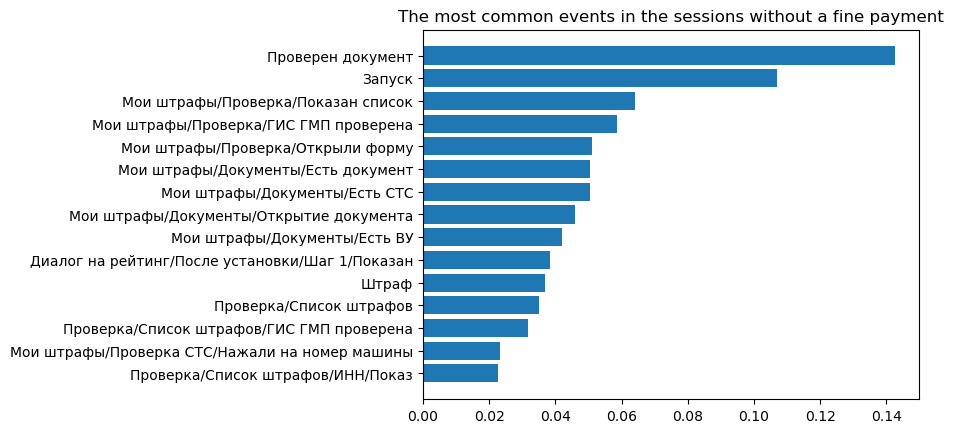

In [50]:
plt.barh(events_without_fine['event_name'][:15], events_without_fine['proportion'][:15])
plt.title("The most common events in the sessions without a fine payment")
plt.gca().invert_yaxis();

In [ ]:
only_in_pay = set(events_with_fine['event_name']) - set(events_without_fine['event_name'])
only_in_nopay = set(events_without_fine['event_name']) - set(events_with_fine['event_name'])
only_in_nopay

In [55]:
only_in_pay

{'Purchase',
 'Мои штрафы/Оплата/Завершили оплату',
 'Мои штрафы/Оплата/Завешили множественную оплату',
 'Мои штрафы/Оплата/Завешили оплату',
 'Мои штрафы/Оплата/По постановлению/Вторая и более оплата',
 'Мои штрафы/Оплата/По постановлению/Завешили оплату',
 'Мои штрафы/Оплата/По пушам/Вторая и более оплата',
 'Мои штрафы/Оплата/По пушам/Завешили множественную оплату',
 'Мои штрафы/Оплата/По пушам/Завешили оплату'}

- **We can try to find the actions presceding fine payment**
- **And compare them with the last events in the sessions without fine payments**

In [ ]:
del(events_without_fine, events_with_fine)

In [57]:
df_week = df_week.sort(['event_datetime', 'user_session_id'])
df_week  = df_week.with_columns([
    pl.col('event_datetime').rank('ordinal', descending=True)
    .over('user_session_id')
    .alias('event_rank')
])

In [58]:
last_5_events = df_week.filter(pl.col('event_rank') < 5)

In [ ]:
with_payments_last_5 = last_5_events.filter(
    pl.col('user_session_id').is_in(sessions_with_payment['user_session_id'].unique())
)
without_payments_last_5 = last_5_events.filter(
    pl.col('user_session_id').is_in(sessions_without_payment['user_session_id'].unique())
)
del(last_5_events)